In [155]:
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
from scipy.optimize import minimize
from matplotlib.backends.backend_pgf import FigureCanvasPgf
matplotlib.backend_bases.register_backend('pdf', FigureCanvasPgf)

matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'text.usetex': True,
    'font.family': 'serif',
    'pgf.rcfonts': False,
})

def read_files(files):
    data = []
    for f in files:
        data += [pd.read_csv(f, sep=',', skipinitialspace=True)]
    return data

dfs = read_files(['data/37.5.csv', 'data/75.csv', 'data/120.csv', 'data/157.5.csv'])


In [156]:
# Подгон всех графиков под одну начальную точку

times = [df['t (s)'] for df in dfs]
voltages = [df['V (mV)'] for df in dfs]

for i in range(1, voltages.__len__()):
    voltages[i] += (voltages[0].iloc[0] - voltages[i].iloc[0])


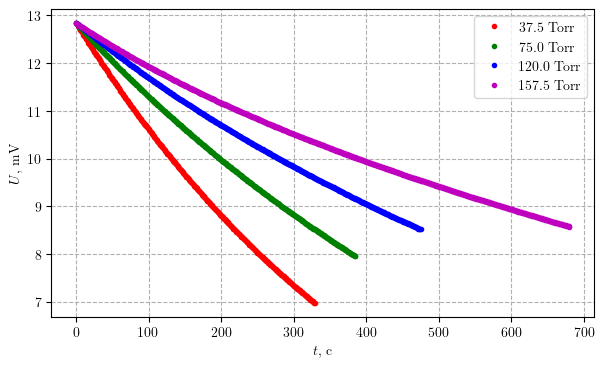

In [157]:
colors = ['red', 'green', 'blue', 'magenta']
labels = ['37.5 Torr', '75.0 Torr', '120.0 Torr', '157.5 Torr']

plt.figure(figsize=(7, 4))

for i in range(times.__len__()):
    plt.errorbar(times[i], voltages[i], fmt=f'{colors[i][0]}.', label=labels[i])

plt.xlabel('$t$, c')
plt.ylabel('$U$, mV')
plt.grid(linestyle='--')
plt.legend()
plt.savefig('pictures/raw.pdf')

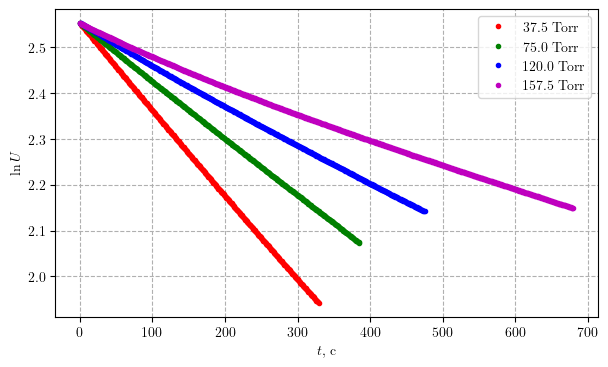

In [158]:
# Линеаризация

plt.figure(figsize=(7, 4))
log_volt = [np.log(v) for v in voltages]

a_coeffs = pd.DataFrame()
pressures = [37.5, 75, 120, 157.5]
a_coeffs['$P$, торр'] = pressures
a_vals = []
delta_as = []
eps_as = []

A_MULTIPLIER = 1e4

for i in range(times.__len__()):
    plt.errorbar(times[i], log_volt[i], fmt=f'{colors[i][0]}.', label=labels[i])
    [a, b], cov = np.polyfit(times[i], log_volt[i], deg=1, cov=True)
    a *= A_MULTIPLIER
    delta_a = np.sqrt(np.diag(cov))[0] * A_MULTIPLIER
    eps_a = delta_a / a * 100
    a_vals.append(a)
    delta_as.append(delta_a)
    eps_as.append(eps_a)

plt.xlabel('$t$, c')
plt.ylabel('$\ln U$')
plt.grid(linestyle='--')
plt.legend()
plt.savefig('pictures/lin.pdf')


In [159]:
import re

D_ERR = 0.011 # Из данных установки
a_coeffs['$-1/\\tau$, $10^4$ c$^{-1}$'] = a_vals
a_coeffs['$\\Delta (-1/\\tau)$, $10^4$ c$^{-1}$'] = delta_as
a_coeffs['$\\varepsilon_{-1/\\tau}$, \\%'] = eps_as
diff = [-0.6 * a for a in a_vals]
diff_err = [d * D_ERR for d in diff]
a_coeffs['$D$, $10^4$ м$^2$/c'] = diff
a_coeffs['$\\Delta D$, $10^4$ м$^2$/c'] = diff_err
a_coeffs['$\\varepsilon_D$, \\%'] = [D_ERR * 100] * 4

tex_content = a_coeffs.to_latex(index=False, escape=False, position='h!', float_format='%.2f')

re_borders = re.compile(r"begin\{tabular\}\{([^\}]+)\}")
borders = re_borders.findall(tex_content)[0]
borders = '|'.join(list(borders))
tex_content = re_borders.sub("begin{tabular}{" + borders + "}", tex_content)

print(tex_content)

\begin{table}[h!]
\centering
\begin{tabular}{r|r|r|r|r|r|r}
\toprule
 $P$, торр &  $-1/\tau$, $10^4$ c$^{-1}$ &  $\Delta (-1/\tau)$, $10^4$ c$^{-1}$ &  $\varepsilon_{-1/\tau}$, \% &  $D$, $10^4$ м$^2$/c &  $\Delta D$, $10^4$ м$^2$/c &  $\varepsilon_D$, \% \\
\midrule
     37.50 &                      -18.58 &                                 0.01 &                        -0.06 &                11.15 &                        0.12 &                 1.10 \\
     75.00 &                      -12.42 &                                 0.01 &                        -0.04 &                 7.45 &                        0.08 &                 1.10 \\
    120.00 &                       -8.62 &                                 0.01 &                        -0.11 &                 5.17 &                        0.06 &                 1.10 \\
    157.50 &                       -5.83 &                                 0.01 &                        -0.21 &                 3.50 &                        0.0

/tmp/ipykernel_16673/1556990349.py:13: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  tex_content = a_coeffs.to_latex(index=False, escape=False, position='h!', float_format='%.2f')


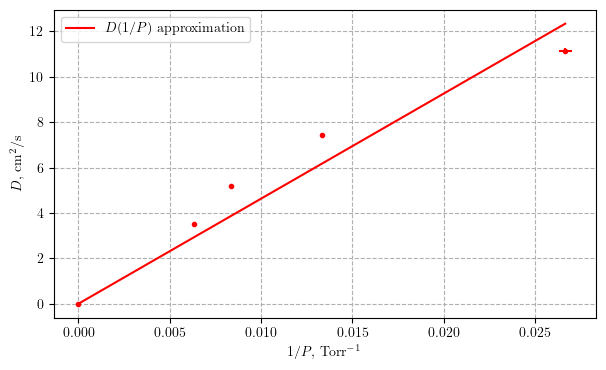

In [164]:
def fit(f, par, x, y):
    """Аргументы:
    f - функция, которую мы хотим оптимизировать.
    params - начальное состояние параметров, можно просто передать нули,
    главное чтоб их было нужное количество
    x, y - точки, под которые подгоняем функцию
    """
    if len(x) != len(y):
        raise "Иксов должно быть столько же, сколько и игреков"
    def err(par, x_, y_):
        y1 = f(par, x_)
        return np.sum((y1-y_)**2)
    return minimize(err, [par], args=(x, y)).x[0]

def proportional(par, x):
    return par * x

# График D(1/P)
plt.figure(figsize=(7, 4))

inv_p = [1 / p for p in pressures]
plt.errorbar(inv_p + [0], diff + [0],
             xerr=[inv_p[i] * 0.5 / pressures[i] for i in range(inv_p.__len__())] + [0],
             yerr=diff_err + [0], fmt='r.')
x_linspace = np.linspace(0, max(inv_p), 1000)
par = 0
par = fit(proportional, par, inv_p, diff)
a = par
devs = [(diff[i] - a * inv_p[i])**2 for i in range(inv_p.__len__())]
mse = np.sqrt(np.mean(devs)) / max(inv_p)
plt.plot(x_linspace, a * x_linspace, color='red', label='$D(1/P)$ approximation')

plt.xlabel('$1/P$, Torr$^{-1}$')
plt.ylabel('$D$, cm$^2$/s')
plt.grid(linestyle='--')
plt.legend()
plt.savefig('pictures/diff.pdf')


In [161]:
mse

84.71599429178208

In [167]:
diff0 = a * 1 / 760
sigma_diff0 = mse / a * diff0
print(f'$$ D_0 = ({diff0:.2f} \\pm {sigma_diff0:.2f})\\ \\text{{см}}^2/\\text{{c}},'
      f'\\ \\varepsilon_{{D_0}} = {sigma_diff0 / diff0 * 100:.0f} \\% $$')


$$ D_0 = (0.61 \pm 0.06)\ \text{см}^2/\text{c},\ \varepsilon_{D_0} = 9 \% $$
